In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from database.people_db import people_db


In [5]:
DATASET_PATH = "datasets"
IMG_SIZE = 64

images = []
labels = []

for dataset_type in os.listdir(DATASET_PATH):   # att, custom
    dataset_path = os.path.join(DATASET_PATH, dataset_type)

    if not os.path.isdir(dataset_path):
        continue

    for person in os.listdir(dataset_path):     # s1, s2, C001
        person_path = os.path.join(dataset_path, person)

        if not os.path.isdir(person_path):
            continue

        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue   # safety check

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(person)

In [6]:
images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels count:", len(labels))

Images shape: (445, 64, 64)
Labels count: 445


In [7]:
# Normalize pixel values
images = images / 255.0

# Reshape for CNN
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Images shape (after reshape):", images.shape)


Images shape (after reshape): (445, 64, 64, 1)


In [8]:
# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# One-hot encoding
labels_categorical = to_categorical(labels_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (356, 64, 64, 1)
Testing data: (89, 64, 64, 1)


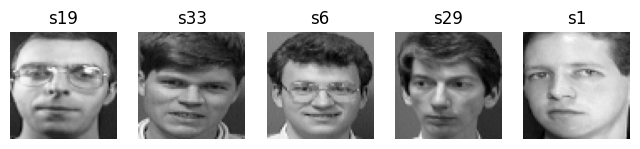

In [9]:
plt.figure(figsize=(8,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(le.inverse_transform([np.argmax(y_train[i])])[0])
    plt.axis('off')
plt.show()


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout,
    Input
)


In [11]:
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(y_train.shape[1], activation='softmax')
])


In [12]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,897 (6.22 MB)

 Trainable params: 1,630,897 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.0225 - loss: 3.9379 - val_accuracy: 0.0562 - val_loss: 3.8759
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.0393 - loss: 3.8561 - val_accuracy: 0.0787 - val_loss: 3.8218
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.0674 - loss: 3.7879 - val_accuracy: 0.1461 - val_loss: 3.6853
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.1208 - loss: 3.5929 - val_accuracy: 0.2247 - val_loss: 3.4771
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1461 - loss: 3.3622 - val_accuracy: 0.4270 - val_loss: 3.1167
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2388 - loss: 3.0023 - val_accuracy: 0.5056 - val_loss: 2.6027
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3596 - loss: 2.4673 - val_accuracy: 0.6067 - val_loss: 2.0475
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3989 - loss: 2.0986 - val_accuracy: 0.6742 - v

In [15]:
model.save("face_model.h5")

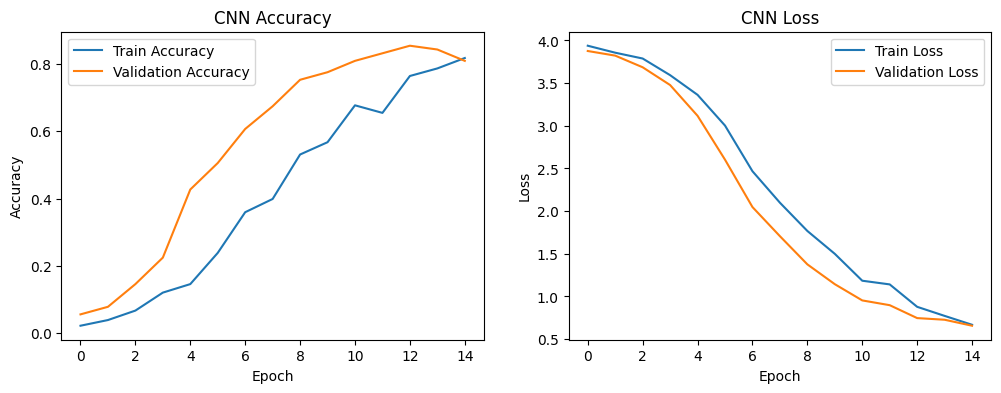

In [16]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8090 - loss: 0.6573
Test Accuracy: 0.8089887499809265


In [18]:
def cnn_predict(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    pred = model.predict(img)
    confidence = np.max(pred)
    predicted_class = np.argmax(pred)

    return predicted_class, confidence


In [19]:
label, conf = cnn_predict("datasets/Custom/C4/3.jpg")

print("Predicted class index:", label)
print("Confidence:", conf)

print("Actual person:", "C4")
print("Predicted person:", le.inverse_transform([label])[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted class index: 3
Confidence: 0.9092244
Actual person: C4
Predicted person: C4


In [20]:
for img in ["datasets/AT&T/s1/8.pgm", "datasets/Custom/C3/1.jpg", "datasets/Custom/C4/1.jpg"]:
    label, conf = cnn_predict(img)
    print(img,
          "→ Predicted:", le.inverse_transform([label])[0],
          "Confidence:", round(conf, 3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
datasets/AT&T/s1/8.pgm → Predicted: s1 Confidence: 0.988
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
datasets/Custom/C3/1.jpg → Predicted: C3 Confidence: 0.923
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
datasets/Custom/C4/1.jpg → Predicted: C4 Confidence: 0.928


In [21]:
import glob

for img_path in glob.glob("testimages/Mahatma Gandhi.jpg"):
    label, conf = cnn_predict(img_path)
    person = le.inverse_transform([label])[0]

    print(f"{img_path} → Predicted: {person}, Confidence: {conf:.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
testimages/Mahatma Gandhi.jpg → Predicted: s34, Confidence: 0.201


In [22]:
def predict_with_unknown(image_path, threshold=0.55):
    label, conf = cnn_predict(image_path)
    
    if conf < threshold:
        return "Unknown", conf
    else:
        return le.inverse_transform([label])[0], conf


In [23]:
name, conf = predict_with_unknown("datasets/AT&T/s37/3.pgm")
print(name, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
s37 0.73309165


In [24]:
name, conf = predict_with_unknown("datasets/Custom/C8/3.jpg")
print(name, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
C8 0.85020864


In [25]:
name, conf = predict_with_unknown("datasets/Custom/C6/5.jpg")
print(name, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
C6 0.9879901


In [27]:
name, conf = predict_with_unknown("testimages/Mahatma Gandhi.jpg")
print(name, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Unknown 0.20073977


In [28]:
def show_prediction(image_path, threshold=0.55):
    # Predict
    name, conf = predict_with_unknown(image_path, threshold)
    
    # Read original image (for display)
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis('off')
    
    title_text = f"Prediction: {name}\nConfidence: {conf:.2f}"
    plt.title(title_text)
    
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


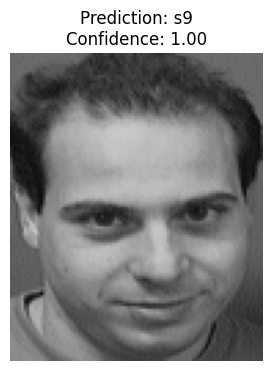

In [29]:
show_prediction("datasets/AT&T/s9/3.pgm")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


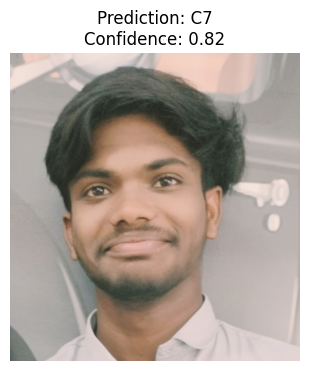

In [30]:
show_prediction("datasets/Custom/C7/3.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


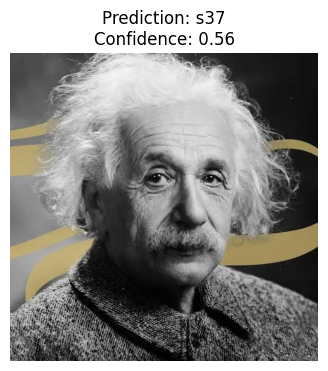

In [31]:

show_prediction("testimages/Albert Einstein.jpg")


In [32]:
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.models import Model

feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output  # Dense(128)
)


In [33]:
from numpy.linalg import norm

def extract_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    
    features = feature_model.predict(img)
    
    # 🔑 L2 normalize features
    features = features / norm(features)
    
    return features

In [34]:
def compare_faces(img1_path, img2_path, threshold=0.85):
    feat1 = extract_features(img1_path)
    feat2 = extract_features(img2_path)
    
    similarity = cosine_similarity(feat1, feat2)[0][0]
    
    if similarity > threshold:
        return "Same Person", similarity
    else:
        return "Different Persons", similarity


In [35]:
def extract_prediction_vector(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    
    pred = model.predict(img)
    return pred


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

def verify_faces(img1_path, img2_path, threshold=0.90):
    p1 = extract_prediction_vector(img1_path)
    p2 = extract_prediction_vector(img2_path)
    
    similarity = cosine_similarity(p1, p2)[0][0]
    
    if similarity > threshold:
        return "Same Person", similarity
    else:
        return "Different Persons", similarity


In [37]:
r1, s1 = verify_faces(
    "datasets/Custom/C3/1.jpg",
    "datasets/Custom/C3/2.jpg"
)
print( r1, s1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Same Person 0.99860865


In [38]:
r2, s2 = verify_faces(
    "datasets/Custom/C5/2.jpg",
    "datasets/Custom/C6/4.jpg"
)
print( r2, s2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Different Persons 0.05692707


In [39]:
def build_person_template(person_folder):
    vectors = []
    
    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        vec = extract_prediction_vector(img_path)
        vectors.append(vec)
    
    return np.mean(vectors, axis=0)


In [40]:
def verify_with_template(image_path, template, threshold=0.85):
    vec = extract_prediction_vector(image_path)
    similarity = cosine_similarity(vec, template)[0][0]
    
    if similarity > threshold:
        return "Same Person", similarity
    else:
        return "Different Person", similarity


In [41]:
import os
import numpy as np

def build_all_templates(dataset_path):
    templates = {}
    
    for person in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person)
        
        if not os.path.isdir(person_path):
            continue
        
        vectors = []
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            vec = extract_prediction_vector(img_path)
            vectors.append(vec)
        
        # Average vector = template
        templates[person] = np.mean(vectors, axis=0)
    
    return templates


In [42]:
def build_all_templates(dataset_path):

    templates = {}

    for dataset_type in os.listdir(dataset_path):
        dataset_type_path = os.path.join(dataset_path, dataset_type)
        if not os.path.isdir(dataset_type_path):
            continue

        for person in os.listdir(dataset_type_path):
            person_path = os.path.join(dataset_type_path, person)
            if not os.path.isdir(person_path):
                continue

            vectors = []

            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)

                if not img_name.lower().endswith(('.jpg', '.png', '.pgm')):
                    continue

                vec = extract_prediction_vector(img_path)
                if vec is not None:        # ✅ HERE
                    vectors.append(vec)

            if len(vectors) > 0:
                templates[person] = np.mean(vectors, axis=0)

    return templates

In [43]:
templates = build_all_templates("datasets")
print(templates.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

def verify_against_all(image_path, templates, threshold=0.85):
    vec = extract_prediction_vector(image_path)
    
    best_person = "Unknown"
    best_score = -1
    
    for person, template in templates.items():
        score = cosine_similarity(vec, template)[0][0]
        if score > best_score:
            best_score = score
            best_person = person
    
    if best_score < threshold:
        return "Unknown", best_score
    else:
        return best_person, best_score


In [45]:
person, score = verify_against_all(
    "datasets/Custom/C4/2.jpg",
    templates
)

print("Prediction:", person)
print("Confidence:", score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction: C4
Confidence: 0.9876824


In [46]:
def identify_person(image_path, templates, threshold=0.85):
    vec = extract_prediction_vector(image_path)
    
    best_person = "Unknown"
    best_score = -1
    
    for person, template in templates.items():
        score = cosine_similarity(vec, template)[0][0]
        if score > best_score:
            best_score = score
            best_person = person
    
    if best_score < threshold:
        return "Unknown", best_score
    else:
        return best_person, best_score


In [47]:
def verify_two_images(img1_path, img2_path, templates, threshold=0.85):
    person1, score1 = identify_person(img1_path, templates, threshold)
    person2, score2 = identify_person(img2_path, templates, threshold)
    
    if person1 == "Unknown" or person2 == "Unknown":
        return "Cannot Verify (Unknown Face)", person1, person2, score1, score2
    
    if person1 == person2:
        return "Same Person", person1, person2, score1, score2
    else:
        return "Different Persons", person1, person2, score1, score2


In [48]:
result, p1, p2, s1, s2 = verify_two_images(
    "datasets/Custom/C4/4.jpg",
    "datasets/Custom/C6/4.jpg",
    templates
)

print(result)
print("Image 1 identified as:", p1, "score:", round(s1,3))
print("Image 2 identified as:", p2, "score:", round(s2,3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Different Persons
Image 1 identified as: C4 score: 0.988
Image 2 identified as: C6 score: 0.99


In [56]:
result, p1, p2, s1, s2 = verify_two_images(
    "datasets/Custom/C1/1.jpg",
    "datasets/Custom/C2/3.jpg",
    templates
)

print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Different Persons


In [57]:
from sklearn.metrics.pairwise import cosine_similarity

def verify_two_images(img1_path, img2_path, templates, threshold=0.85):

    # Predict both images against templates
    p1, s1 = verify_against_all(img1_path, templates, threshold)
    p2, s2 = verify_against_all(img2_path, templates, threshold)

    # Decision logic
    if p1 == "Unknown" or p2 == "Unknown":
        result = "At least one image is Unknown"
    elif p1 == p2:
        result = "Same Person"
    else:
        result = "Different Persons"

    return result, p1, p2, s1, s2

In [58]:
def show_verification_result(img1_path, img2_path, templates, threshold=0.85):
    # Verify
    result, p1, p2, s1, s2 = verify_two_images(
        img1_path, img2_path, templates, threshold
    )
    
    # Read images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # Display side by side
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.axis('off')
    plt.title(f"Image 1\nID: {p1}\nScore: {s1:.2f}")
    
    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.axis('off')
    plt.title(f"Image 2\nID: {p2}\nScore: {s2:.2f}")
    
    plt.suptitle(f"Verification Result: {result}", fontsize=14)
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


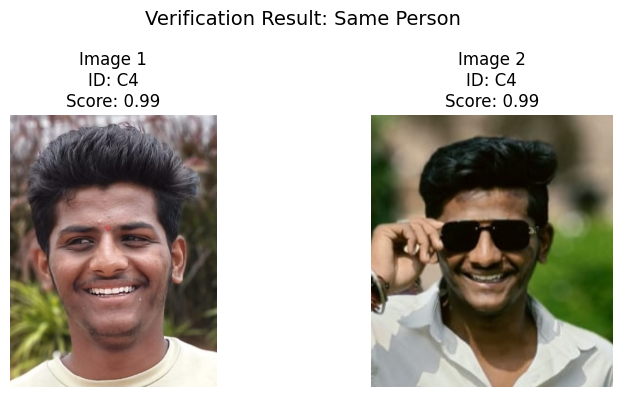

In [59]:
show_verification_result(
    "datasets/Custom/C4/4.jpg",
    "datasets/Custom/C4/1.jpg",
    templates
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


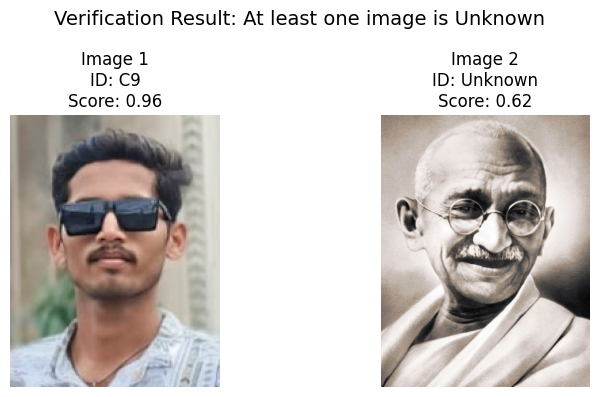

In [62]:
show_verification_result(
    "datasets/Custom/C9/2.jpg",
    "testimages/Mahatma Gandhi.jpg",
    templates
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


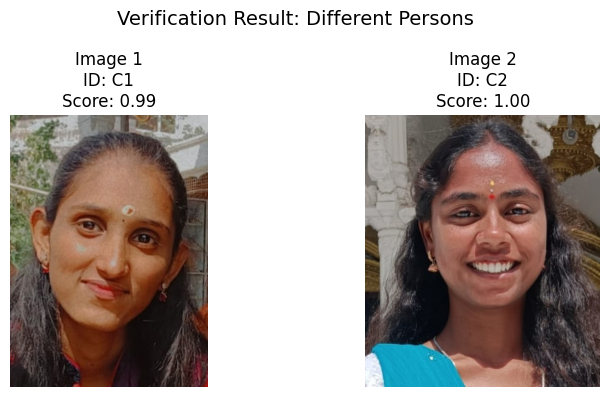

In [63]:
show_verification_result(
    "datasets/Custom/C1/1.jpg",
    "datasets/Custom/C2/1.jpg",
    templates
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


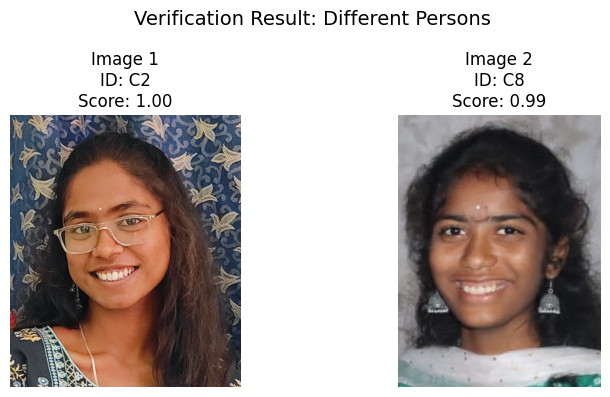

In [64]:
show_verification_result(
    "datasets/Custom/C2/3.jpg",
    "datasets/Custom/C8/1.jpg",
    templates
)


In [65]:
import os
print(os.getcwd())

c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN


In [66]:
import sys
print(sys.path)

['c:\\Program Files\\Python310\\python310.zip', 'c:\\Program Files\\Python310\\DLLs', 'c:\\Program Files\\Python310\\lib', 'c:\\Program Files\\Python310', '', 'C:\\Users\\R. Akanksha Rani\\AppData\\Roaming\\Python\\Python310\\site-packages', 'c:\\Program Files\\Python310\\lib\\site-packages']


In [67]:
from database.people_db import *
print(get_person_by_id("C5"))

{'name': 'Pushpan', 'age': 22, 'email': 'pushpan@gmail.com', 'mobile': '7337528757', 'image': 'datasets/Custom/C5.jpg'}


In [68]:
pid, details = get_person_by_email("akanksharanir@gmail.com")
print(pid, details)

C2 {'name': 'Akanksha', 'age': 20, 'email': 'akanksharanir@gmail.com', 'mobile': '8639575597', 'image': 'datasets/Custom/C2.jpg'}


In [69]:
pid, details = get_person_by_mobile("6302694985")
print(pid, details)

C7 {'name': 'Sampath', 'age': 19, 'email': 'malleboinasampath@gmail.com', 'mobile': '6302694985', 'image': 'datasets/Custom/C7.jpg'}


In [70]:
add_person("C10", "Meena", 21, "meena@gmail.com", "8899001122")

print(get_person_by_id("C10"))

{'name': 'Meena', 'age': 21, 'email': 'meena@gmail.com', 'mobile': '8899001122'}


In [71]:
from database.people_db import *

In [72]:
from database.people_db import find_person

pid, details, image_path = find_person("C1")

print("ID:", pid)
print("Details:", details)
print("Image path:", image_path)

ID: C1
Details: {'name': 'Aishwarya', 'age': 20, 'email': 'bokkiaishwarya@gmail.com', 'mobile': '9392512067', 'image': 'datasets/Custom/C1.jpg'}
Image path: c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C1\1.jpg


In [73]:
pid, details, image_path = find_person("C9")

print("ID:", pid)
print("Details:", details)
print("Image:", image_path)

ID: C9
Details: {'name': 'Varun', 'age': 21, 'email': 'varun@gmail.com', 'mobile': '9063356562', 'image': 'datasets/Custom/C9.jpg'}
Image: c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C9\1.jpg


In [74]:
pid, details, image_path = find_person("akanksharanir@gmail.com")
print(pid, details, image_path)

C2 {'name': 'Akanksha', 'age': 20, 'email': 'akanksharanir@gmail.com', 'mobile': '8639575597', 'image': 'datasets/Custom/C2.jpg'} c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C2\1.jpg


In [75]:
pid, details, image_path = find_person("9063356562")
print(pid, details, image_path)

C9 {'name': 'Varun', 'age': 21, 'email': 'varun@gmail.com', 'mobile': '9063356562', 'image': 'datasets/Custom/C9.jpg'} c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C9\1.jpg


In [76]:
find_person("C1")

('C1',
 {'name': 'Aishwarya',
  'age': 20,
  'email': 'bokkiaishwarya@gmail.com',
  'mobile': '9392512067',
  'image': 'datasets/Custom/C1.jpg'},
 'c:\\Users\\R. Akanksha Rani\\OneDrive\\Documents\\Projects\\Face Recog ANN\\datasets\\Custom\\C1\\1.jpg')

In [77]:
from database import people_db
import inspect

print(inspect.getsource(people_db.find_person))

def find_person(value):

    pid = None
    details = None
    image_path = None

    # Search by ID
    if value in people_db:
        pid = value
        details = people_db[pid]
    else:
        for person_id, info in people_db.items():
            if info["email"] == value or info["mobile"] == value:
                pid = person_id
                details = info
                break

    if pid is None:
        return None, None, None

    # Fetch image
    person_folder = os.path.join(CUSTOM_DATASET_PATH, pid)

    if os.path.exists(person_folder):
        for f in os.listdir(person_folder):
            if f.lower().endswith((".jpg", ".png", ".jpeg")):
                image_path = os.path.join(person_folder, f)
                break

    return pid, details, image_path



In [78]:
from database import people_db

print(people_db.__file__)

c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\database\people_db.py


In [79]:
from database import people_db
import inspect

print(inspect.getsource(people_db))

# database/people_db.py

people_db = {
    "C1": {
        "name": "Aishwarya",
        "age": 20,
        "email": "bokkiaishwarya@gmail.com",
        "mobile": "9392512067",
        "image" : "datasets/Custom/C1.jpg"
    },
    "C2": {
        "name": "Akanksha",
        "age": 20,
        "email": "akanksharanir@gmail.com",
        "mobile": "8639575597",
        "image" : "datasets/Custom/C2.jpg"
    },
    "C3": {
        "name": "Lohith",
        "age": 20,
        "email": "lohith@gmail.com",
        "mobile": "9876543210",
        "image" : "datasets/Custom/C3.jpg"    
    },
    "C4": {
        "name": "Praveen",
        "age": 20,
        "email": "praveen@gmail.com",
        "mobile": "8522816126",
        "image" : "datasets/Custom/C4.jpg"
    },
    "C5": {
        "name": "Pushpan",
        "age": 22,
        "email": "pushpan@gmail.com",
        "mobile": "7337528757",
        "image" : "datasets/Custom/C5.jpg"
    },
    "C6": {
        "name": "Raj Ratan",
        "age

In [80]:
from database.people_db import find_person

pid, details, image_path = find_person("C1")

print("ID:", pid)
print("Details:", details)
print("Image path:", image_path)

ID: C1
Details: {'name': 'Aishwarya', 'age': 20, 'email': 'bokkiaishwarya@gmail.com', 'mobile': '9392512067', 'image': 'datasets/Custom/C1.jpg'}
Image path: c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C1\1.jpg


In [82]:
import os

print(os.listdir("datasets"))

['AT&T', 'Custom']


In [83]:
print(os.listdir("datasets/Custom"))

['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']


In [84]:
print(os.listdir("datasets/Custom/C1"))

['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


In [85]:
from database.people_db import find_person

pid, details, image_path = find_person("C3")

print("ID:", pid)
print("Details:", details)
print("Image path:", image_path)

ID: C3
Details: {'name': 'Lohith', 'age': 20, 'email': 'lohith@gmail.com', 'mobile': '9876543210', 'image': 'datasets/Custom/C3.jpg'}
Image path: c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C3\1.jpg


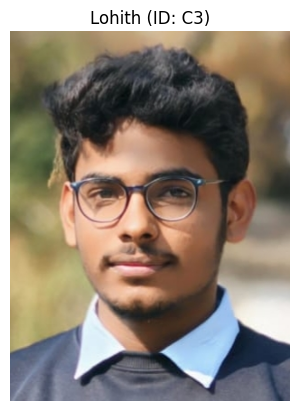

In [86]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title(f"{details['name']} (ID: {pid})")
plt.show()

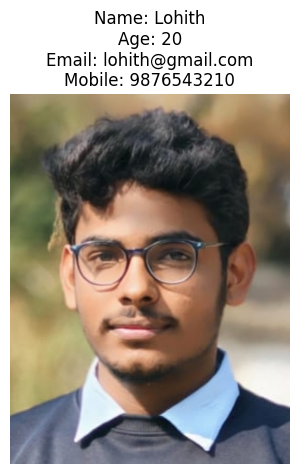

In [156]:
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Name: {details['name']}\n"
    f"Age: {details['age']}\n"
    f"Email: {details['email']}\n"
    f"Mobile: {details['mobile']}"
)
plt.show()

ID: C7
Details: {'name': 'Sampath', 'age': 19, 'email': 'malleboinasampath@gmail.com', 'mobile': '6302694985', 'image': 'datasets/Custom/C7.jpg'}
Image path: c:\Users\R. Akanksha Rani\OneDrive\Documents\Projects\Face Recog ANN\datasets\Custom\C7\1.jpg


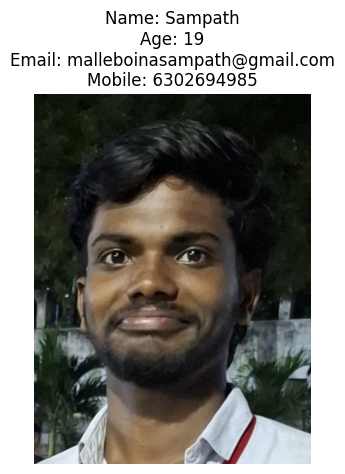

In [87]:
from database.people_db import find_person

pid, details, image_path = find_person("C7")

print("ID:", pid)
print("Details:", details)
print("Image path:", image_path)
plt.imshow(img)
plt.axis("off")
import cv2
import matplotlib.pyplot as plt                                     

img = cv2.imread(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title(f"{details['name']} (ID: {pid})")
plt.title(
    f"Name: {details['name']}\n"
    f"Age: {details['age']}\n"
    f"Email: {details['email']}\n"
    f"Mobile: {details['mobile']}"
)
plt.show()
plt.show()


In [88]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)